# ML Training with yProv4ML

This notebook contains an example of how to integrate the yProv4ML library in an already existing ML training run.
The initial part will describe the classic ML workflow, followed by an integration phase of the yProv4ML directives, and finally an additional section on how to use the data collected during the execution.

Main Authors:
- Gabriele Padovani (gabriele.padovani@unitn.it)
- Sandro Fiore (sandro.fiore@unitn.it)

For more information:
- [Library](https://github.com/HPCI-Lab/yProv4ML)
- [Docs](https://hpci-lab.github.io/yProv4ML/)
- [yProv Website](https://hpci-lab.github.io/yprov.github.io/)

Lets define some constants and import all the necessary libraries:

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
import matplotlib.pyplot as plt

PATH_DATASETS = "./data"
BATCH_SIZE = 32
EPOCHS = 10
DEVICE = "cpu"

The model architecture:

In [19]:
class MNISTModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = torch.nn.Sequential(
            torch.nn.Linear(28 * 28, 128),
            torch.nn.Linear(128, 10),
            torch.nn.ReLU(),
        )

    def forward(self, x):
        return self.model(x.view(x.size(0), -1))

mnist_model = MNISTModel().to(DEVICE)

The dataset we will use, along with loss and optimizer:

In [20]:
tform = transforms.Compose([
    transforms.ToTensor()
])
train_ds = MNIST(PATH_DATASETS, train=True, download=True, transform=tform)
train_ds = Subset(train_ds, range(BATCH_SIZE*200))
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

test_ds = MNIST(PATH_DATASETS, train=False, download=True, transform=tform)
test_ds = Subset(test_ds, range(BATCH_SIZE*5))
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

optim = torch.optim.Adam(mnist_model.parameters(), lr=0.0001)
loss_fn = nn.MSELoss().to(DEVICE)

Run everything:

100%|██████████| 5/5 [00:00<00:00, 194.75it/s]


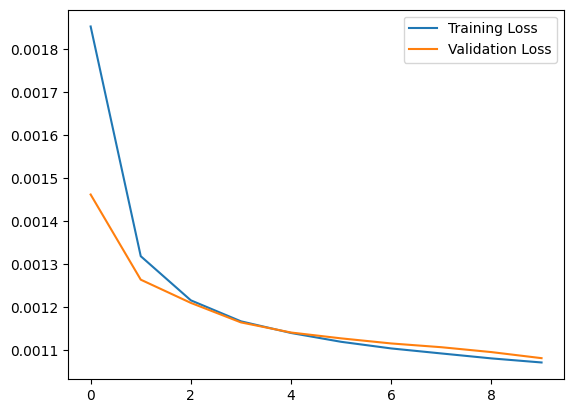

Final loss: 0.0011


In [21]:
epoch_losses = []
val_losses = []
for epoch in range(EPOCHS):
    loss_c = 0.0
    mnist_model.train()
    for x, y in tqdm(train_loader):
        x, y = x.to(DEVICE), y.to(DEVICE)
        optim.zero_grad()
        y_hat = mnist_model(x)
        y = F.one_hot(y, 10).float()
        loss = loss_fn(y_hat, y)
        loss.backward()
        optim.step()
        loss_c += loss.item()
    epoch_losses.append(loss_c / len(train_loader.dataset))

    mnist_model.eval()
    loss_c = 0.0
    with torch.no_grad():
        for (x, y) in tqdm(test_loader):
            x, y = x.to(DEVICE), y.to(DEVICE)
            y_hat = mnist_model(x)
            y2 = F.one_hot(y, 10).float()
            loss_c += loss_fn(y_hat, y2).item()
    val_losses.append(loss_c / len(test_loader.dataset))

plt.plot(epoch_losses, color="tab:blue", label="Training Loss")
plt.plot(val_losses, color="tab:orange", label="Validation Loss")
plt.legend()
plt.show()

print(f"Final loss: {epoch_losses[-1]:.4f}")

## Now let's integrate yProv4ML

Install the library first:

In [22]:
%%capture
!pip install -U yprov4ml

Import it, and start the run:

In [23]:
import yprov4ml

yprov4ml.start_run(
    prov_user_namespace="www.example.org",
    experiment_name="example",
    provenance_save_dir="prov",
)

The constants definition remains the same, as well as the model, we just need to reinstantiate it:

In [24]:
mnist_model = MNISTModel().to(DEVICE)
yprov4ml.log_model("mnist_model", mnist_model, context="Training", is_input=True)

Now for the dataset, optimizer and loss, lets log all this information in the proveance document:

In [25]:
tform = transforms.Compose([transforms.ToTensor()])
yprov4ml.log_param("dataset transformation", tform)

train_ds = MNIST(PATH_DATASETS, train=True, download=True, transform=tform)
train_ds = Subset(train_ds, range(BATCH_SIZE*200))
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
yprov4ml.log_dataset("train_dataset", train_loader, context="Training")

test_ds = MNIST(PATH_DATASETS, train=False, download=True, transform=tform)
test_ds = Subset(test_ds, range(BATCH_SIZE*5))
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)
yprov4ml.log_dataset("val_dataset", test_loader, context="Validation")

optim = torch.optim.Adam(mnist_model.parameters(), lr=0.0001)
yprov4ml.log_param("optimizer", "Adam")

loss_fn = nn.MSELoss().to(DEVICE)
yprov4ml.log_param("loss_fn", "MSELoss")

And lets change the training process to include logging functions:

In [26]:
for epoch in range(EPOCHS):
    mnist_model.train()
    for x, y in tqdm(train_loader):
        x, y = x.to(DEVICE), y.to(DEVICE)
        optim.zero_grad()
        y_hat = mnist_model(x)
        y = F.one_hot(y, 10).float()
        loss = loss_fn(y_hat, y)
        loss.backward()
        optim.step()

        yprov4ml.log_metric("MSE", loss.item(), context="Training", step=epoch)
        yprov4ml.log_system_metrics("Training", step=epoch)

    yprov4ml.save_model_version(f"mnist_model_version", mnist_model, "Training", step=epoch)

    mnist_model.eval()
    with torch.no_grad():
        for (x, y) in tqdm(test_loader):
            x, y = x.to(DEVICE), y.to(DEVICE)
            y_hat = mnist_model(x)
            y2 = F.one_hot(y, 10).float()
            loss = loss_fn(y_hat, y2)
        yprov4ml.log_metric("MSE", loss.item(), context="Validation", step=epoch)

yprov4ml.log_model("mnist_model_final", mnist_model, context="Training")

100%|██████████| 5/5 [00:00<00:00, 218.20it/s]


And finally stop the run:

In [27]:
yprov4ml.end_run(create_graph=True, create_svg=True, crate_ro_crate=True)

## Results

Now lets check out what was logged, there is a new directory called `prov`, with:
- `example_0`: the provenance directory
- `example_0.zip`: the RO-Crate

`example_0` contains:
- `artifacts`: a folder containing all files used as input or outputs, the files can be ignored and not copied if too large;
- `metrics`: a folder containing all metrics tracked (including system);
- `prov_example_GR0_0.dot`: the provenance graph representation;
- `prov_example_GR0_0.json`: the W3C provenance JSON file;
- `prov_example_GR0_0.svg`: the provenance graph representation, visualizable as image.

Now lets check some of this information using the included directives. Lets plot the loss, to have the same chart as before:

In [28]:
from yprov4ml.utils import getters as G

jsonpath = "prov/example_0/prov_example_GR0_0.json"

G.list_entities(jsonpath)

['Original_mnist_model.pt//Training',
 'mnist_model.pt//Training',
 'dataset transformation',
 'train_dataset//Training',
 'val_dataset//Validation',
 'optimizer',
 'loss_fn',
 'Original_mnist_model_version_0.pt//Training',
 'mnist_model_version_0.pt//Training',
 'Original_mnist_model_version_1.pt//Training',
 'mnist_model_version_1.pt//Training',
 'Original_mnist_model_version_2.pt//Training',
 'mnist_model_version_2.pt//Training',
 'Original_mnist_model_version_3.pt//Training',
 'mnist_model_version_3.pt//Training',
 'Original_mnist_model_version_4.pt//Training',
 'mnist_model_version_4.pt//Training',
 'Original_mnist_model_version_5.pt//Training',
 'mnist_model_version_5.pt//Training',
 'Original_mnist_model_version_6.pt//Training',
 'mnist_model_version_6.pt//Training',
 'Original_mnist_model_version_7.pt//Training',
 'mnist_model_version_7.pt//Training',
 'Original_mnist_model_version_8.pt//Training',
 'mnist_model_version_8.pt//Training',
 'Original_mnist_model_version_9.pt//Trai

In [29]:
G.list_activities(jsonpath)

['example_GR0_0', 'Training', 'Validation', 'psutil//Training']

In [30]:
G.list_metrics(jsonpath)

,label,context,source,csv_path,prov:type,prov:generatedAtTime,yprov:file_size,prov:role
metric_entity,,,,,,,,
MSE//Training,MSE//Training,Training,None,prov/example_0/metrics_GR0/MSE_Training_None_G...,provml:Metric,2026-06-15T13:48:32.415922,49178,output
psutil//cpu_usage_pct//Training,psutil//cpu_usage_pct//Training,Training,psutil,prov/example_0/metrics_GR0/cpu_usage_pct_Train...,provml:Metric,2026-06-15T13:48:32.416736,42740,output
psutil//cpu_power//Training,psutil//cpu_power//Training,Training,psutil,prov/example_0/metrics_GR0/cpu_power_Training_...,provml:Metric,2026-06-15T13:48:32.416757,42022,output
psutil//cpu_energy//Training,psutil//cpu_energy//Training,Training,psutil,prov/example_0/metrics_GR0/cpu_energy_Training...,provml:Metric,2026-06-15T13:48:32.416767,42022,output
psutil//ram_usage_pct//Training,psutil//ram_usage_pct//Training,Training,psutil,prov/example_0/metrics_GR0/ram_usage_pct_Train...,provml:Metric,2026-06-15T13:48:32.416776,42022,output
psutil//ram_usage_gb//Training,psutil//ram_usage_gb//Training,Training,psutil,prov/example_0/metrics_GR0/ram_usage_gb_Traini...,provml:Metric,2026-06-15T13:48:32.416785,69695,output
psutil//ram_power//Training,psutil//ram_power//Training,Training,psutil,prov/example_0/metrics_GR0/ram_power_Training_...,provml:Metric,2026-06-15T13:48:32.416793,45921,output
psutil//ram_energy//Training,psutil//ram_energy//Training,Training,psutil,prov/example_0/metrics_GR0/ram_energy_Training...,provml:Metric,2026-06-15T13:48:32.416801,74509,output
psutil//disk_usage_gb//Training,psutil//disk_usage_gb//Training,Training,psutil,prov/example_0/metrics_GR0/disk_usage_gb_Train...,provml:Metric,2026-06-15T13:48:32.416808,69461,output


      epoch     value  timestep
0         0  0.094363         0
1         0  0.097760         0
2         0  0.096925         0
3         0  0.090085         0
4         0  0.096608         0
...     ...       ...       ...
1995      9  0.012319         0
1996      9  0.015421         0
1997      9  0.015869         0
1998      9  0.030646         0
1999      9  0.023598         0

[2000 rows x 3 columns]


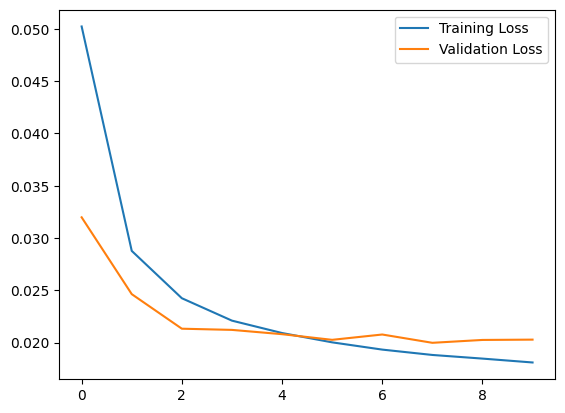

In [31]:
loss_train = G.get_metric(jsonpath, name="MSE", context="Training")
loss_val = G.get_metric(jsonpath, name="MSE", context="Validation")
plt.plot(loss_train.groupby("epoch").mean()["value"], color="tab:blue", label="Training Loss")
plt.plot(loss_val.groupby("epoch").mean()["value"], color="tab:orange", label="Validation Loss")
plt.legend()
plt.show()

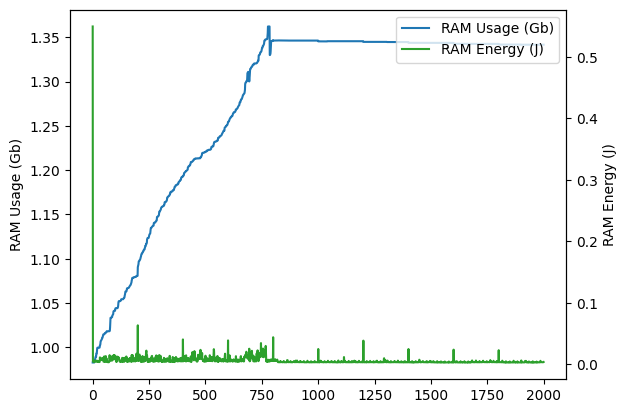

In [32]:
ram_usage_gb = G.get_metric(jsonpath, name="ram_usage_gb", context="Training", source="psutil")
ram_usage_pct = G.get_metric(jsonpath, name="ram_energy", context="Training", source="psutil")

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
l1 = ax1.plot(ram_usage_gb["value"], color="tab:blue", label="RAM Usage (Gb)")
l2 = ax2.plot(ram_usage_pct["value"], color="tab:green", label="RAM Energy (J)")
ax1.set_ylabel("RAM Usage (Gb)")
ax2.set_ylabel("RAM Energy (J)")
plt.legend(l1+l2, ["RAM Usage (Gb)", "RAM Energy (J)"])
plt.show()

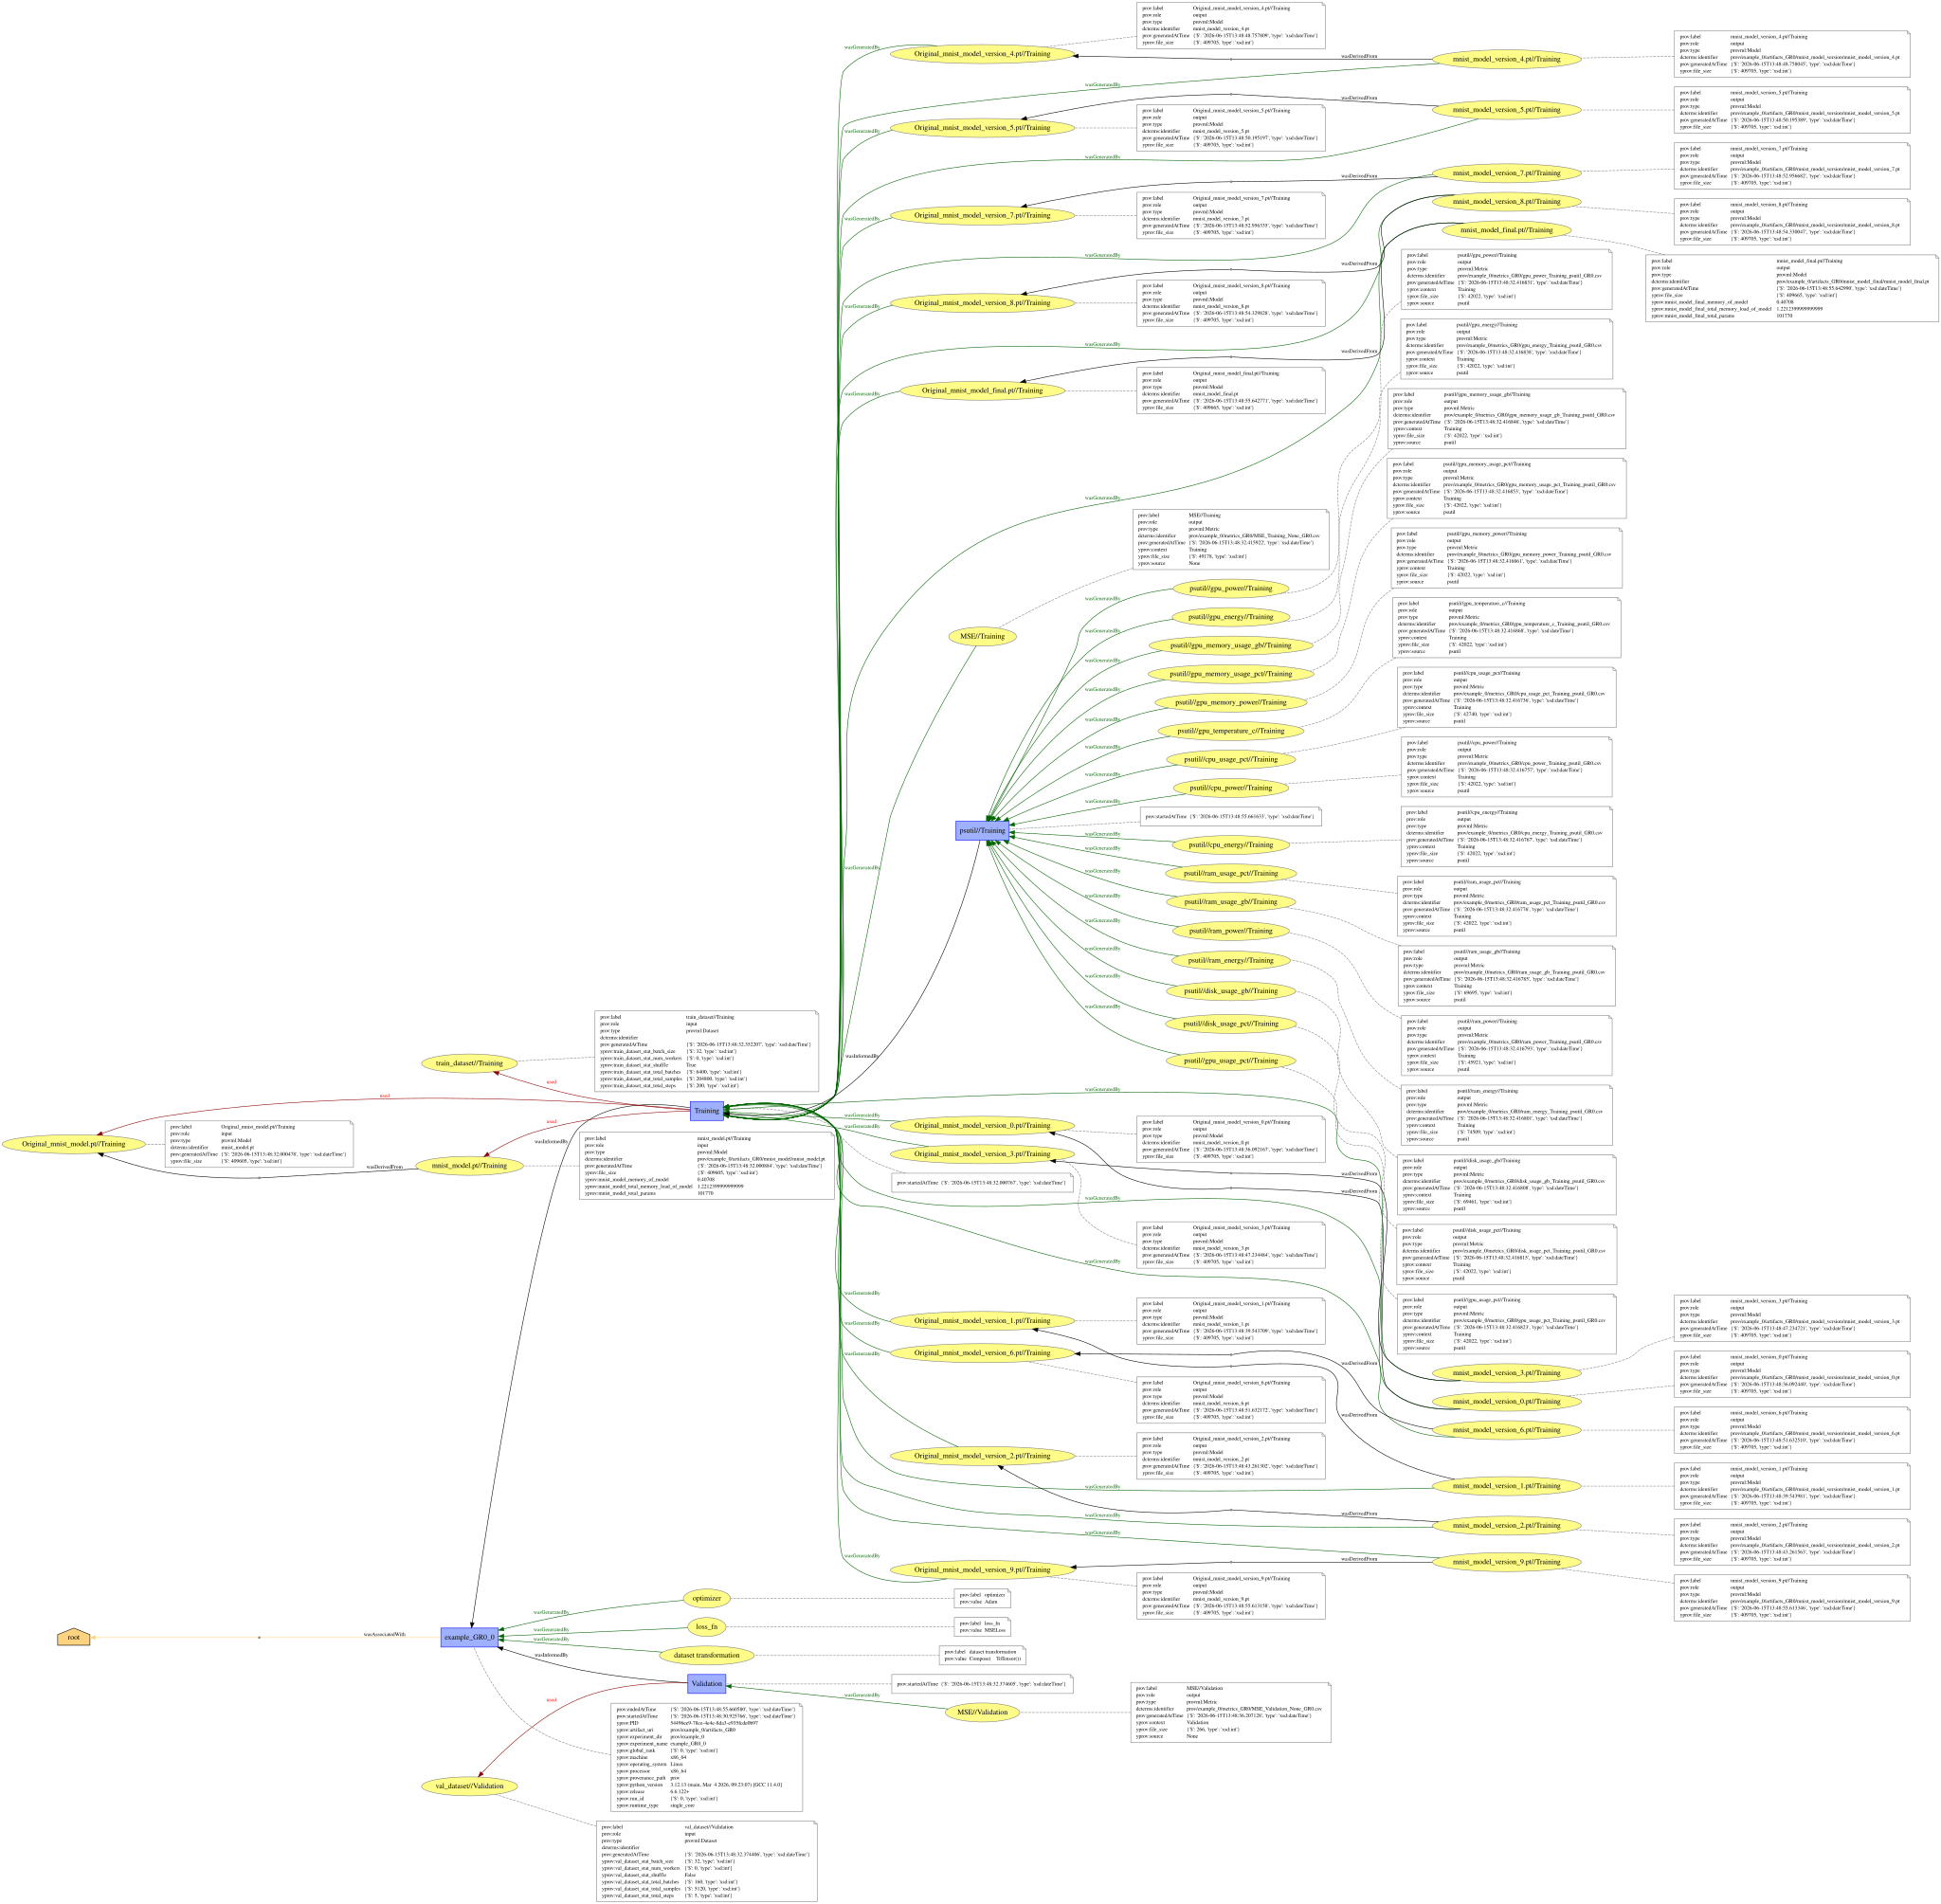

In [33]:
from IPython.display import SVG, display
display(SVG(filename='prov/example_0/prov_example_GR0_0.svg'))